In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import statsmodels.api as sm

**Linear regression, one-parameter case**

We first simulate a few data points randomly scattered around line $Y=\beta X$, where $\beta = -10$. Then we invoke the `OLS` function from the `statsmodels.api` library to fit these data points by least squares linear regression. Ideally, the fitted value for the coefficient should be close to $-10$, the value of $\beta$. Here we also compare the fitted value of $\hat\beta$ to one calculated using the analytical solution: $\hat{\beta}=\frac{\sum_i x_iy_i}{\sum_i x_i^2}$. These two values should match within the numerical precision of the computer.

Our data points:
   X   Y
0 -9  75
1 -8  83
2 -5  49
3 -2  38
----------------------------------------------------------------------------------------------------
Coefficient (fitted): -9.540229885057473
Coefficient (analytical solution): -9.540229885057471
----------------------------------------------------------------------------------------------------
                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   0.968
Model:                            OLS   Adj. R-squared (uncentered):              0.957
Method:                 Least Squares   F-statistic:                              90.98
Date:                Wed, 11 Feb 2026   Prob (F-statistic):                     0.00244
Time:                        13:58:38   Log-Likelihood:                         -15.419
No. Observations:                   4   AIC:                                      32.84
Df Residuals:            

C:\Users\lauyu\AppData\Local\Temp\ipykernel_18968\2141931357.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coeff_fit = model.params[0]
C:\Users\lauyu\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


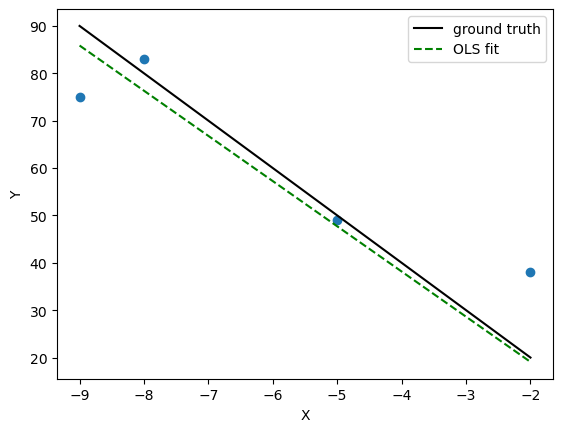

In [2]:
random.seed(2)
# use a random seed to make sure the results are reproducible
# i.e., random number generator will generate the same set of numbers every time

data = []
for _ in range(4):
    x = random.randint(-10, 10)  # Random x-coordinate between -10 and 10
    y = -10 * x + random.randint(-20, 20)  # Adding random noise to y
    data.append((x, y))

# Create a Pandas DataFrame
df = pd.DataFrame(data, columns=['X', 'Y'])

# Display the DataFrame
print("Our data points:")
print(df)

X = df['X']

# Perform linear regression
model = sm.OLS(df['Y'], X).fit() # OLS stands for ordinary least squares

# Obtain the fitted coefficient (beta-hat)
coeff_fit = model.params[0]

#
coeff_calVal = np.sum(df['X'] * df['Y'])/sum(df['X']**2)

# Print and compare the coefficient value obtained by sm.OLS and that obtained directly by the analytical solution
print("-"*100)
print("Coefficient (fitted): " + str(coeff_fit))
print("Coefficient (analytical solution): " + str(coeff_calVal))
print("-"*100)

# Print the complete regression results
print(model.summary())

# Plot the data points, along with the ground truth relation: Y = -10X and the fitted line
plt.scatter(df['X'], df['Y'])
X_line = np.linspace(X.min(), X.max(), 100)
Y_line_true = -10 * X_line
Y_line_fit = coeff_fit * X_line

plt.plot(X_line, Y_line_true, color='black', linestyle='-', label='ground truth')
plt.plot(X_line, Y_line_fit, color='green', linestyle='--', label='OLS fit')

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

**Multiple linear regression using the normal equation**

We first generate 100 artificial data points with feature 1 ($X_1$) values in the range between 0 to 3 and feature 2 ($X_2$) values in the range between 0 and 10. The true relationship between the response and input variables of these data points is $Y = 4 + 3X_1 -2X_2 + \epsilon$ where $\epsilon$ is some random Gaussian noise with mean of 0 and standard deviation of 3. We solve for the coefficients $\hat{\beta_0},\hat{\beta_1},\hat{\beta_2}$ using the normal equation, and use the solved coefficients to predict the $Y$ values for two new data points located at $(0, 2.5)$ and $(1.5, 7)$.

,X_0,X_1,X_2,Y
0,1.0,1.251066,3.266449,1.453763
1,1.0,2.160973,5.270581,1.796899
2,1.0,0.000343,8.859421,-13.020329
3,1.0,0.906998,3.572698,1.623252
4,1.0,0.440268,9.085352,-13.780250
...,...,...,...,...
95,1.0,0.711081,9.319721,-13.439153
96,1.0,2.710139,0.139516,11.845710
97,1.0,1.721038,2.343621,0.286012
98,1.0,0.008611,6.167784,-10.893683


True Coefficients: [ 4  3 -2]
Calculated Coefficients: [ 4.67493405  2.85371161 -2.03507807]
New prediction: [-0.41276113 -5.29004505]


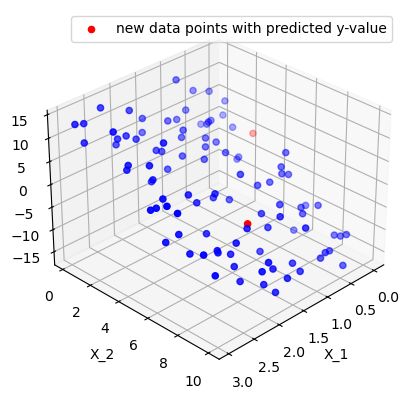

In [3]:
np.random.seed(1)
# set random seed number so the results are reproducible

m = 100 # number of observations
x_1 = 3*np.random.rand(m) # randomly draw m values from a uniform distribution between 0 and 3
x_2 = 10*np.random.rand(m)
theta_true = np.array([4, 3, -2])
# the ground truth alues of the polynomial coefficients that we would like to verify using the normal equation method

y = (theta_true[0] + theta_true[1]*x_1 + theta_true[2]*x_2) + np.random.normal(0, 3, m)
# Generate the Y-values for these data points accoridng to the true relationship, and add some Gaussian noise.

df = pd.DataFrame({'X_1': x_1, 'X_2': x_2, 'Y': y})

df = sm.add_constant(df) # add a dummy variable X_0 = 1 so our model will have a non-zero intercept term beta_0
df.rename(columns={'const': 'X_0'}, inplace=True) # rename the column corresponding to the dummy variable

display(df)

X = df[["X_0", "X_1", "X_2"]].to_numpy() # this is the design matrix

beta_best = np.linalg.inv(X.T @ X) @ X.T @ y #
# the symbol @ denotes matrix (rather than scaler) multiplication

print("True Coefficients:", theta_true)
print("Calculated Coefficients:", beta_best.reshape(-1))

# Now making new predictions using theta_best:
x_new = np.array([[0, 2.5], [1.5, 7]])
X_new = sm.add_constant(x_new)
y_predict = X_new @ beta_best
print("New prediction:", y_predict.reshape(-1))


# Plot the dataset in 3D
# from mpl_toolkits.mplot3d import Axes3D  # Import the 3D plotting module
from mpl_toolkits import mplot3d

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['X_1'], df['X_2'], df['Y'], c='b', marker='o')

ax.set_xlabel('X_1')
ax.set_ylabel('X_2')
ax.set_zlabel('Y')

ax.scatter3D(x_new[:, 0], x_new[:, 1], y_predict, c='r', marker='o', label='new data points with predicted y-value')

ax.legend()
ax.view_init(elev=30, azim=45)
# specify the viewing angle for the 3D plot
# Note: it might seem like some data points are not placed correctly, but in reality they are correct.
# This is just due to the way the data are displayed by scatter3D(), which in my opinion is not ideal.
# But you can verify this by rotating the axis by changing "azim" to 90 or 180, and/or changing "elev" to 0

# Show the plot
plt.show()